<a href="https://www.kaggle.com/code/lalit7881/bike-price-gst-analysis-eda-100?scriptVersionId=318839448" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/shambhurajejagadale/indian-bikes-price-and-gst-analysis-2020-25/indian_bikes_dataset_1000.csv


## Loading dataset

In [2]:
df =pd.read_csv("/kaggle/input/datasets/shambhurajejagadale/indian-bikes-price-and-gst-analysis-2020-25/indian_bikes_dataset_1000.csv")

In [3]:
df.head()

,brand,model,cc,segment,year,speedometer_type,top_speed_kmh,mileage_kmpl,fuel_tank_liters,factory_price_inr,gst_rate_pct,gst_amount_inr,ex_showroom_inr,on_road_price_inr,overall_score,price_increase_scenario_pct,buyer_behaviour,price_sensitivity
0,Honda,Hornet 2.0,184,mid,2020,Digital,137,43.8,10.1,100781,28.0,28219,129000,147604,70,9.3,Will likely switch brand,High
1,Bajaj,Pulsar N250,249,mid,2024,Digital,157,33.2,14.9,123438,28.0,34562,158000,185890,71,4.1,Might reconsider,Medium
2,Hero,Splendor Plus,97,budget,2020,Analog,95,64.2,8.7,60156,28.0,16844,77000,89751,57,2.3,Might reconsider,Medium
3,Royal Enfield,Thunderbird 350X,346,premium,2025,Semi-Digital,152,29.1,17.3,146875,28.0,41125,188000,221689,67,8.7,Will likely switch brand,High
4,Royal Enfield,Scram 411,411,premium,2023,Semi-Digital,165,23.4,14.9,166412,31.0,51588,218000,251257,73,13.1,Will definitely switch,Very High


In [4]:
df.tail()

,brand,model,cc,segment,year,speedometer_type,top_speed_kmh,mileage_kmpl,fuel_tank_liters,factory_price_inr,gst_rate_pct,gst_amount_inr,ex_showroom_inr,on_road_price_inr,overall_score,price_increase_scenario_pct,buyer_behaviour,price_sensitivity
995,Yamaha,R3,321,premium,2020,Digital,144,33.6,15.0,360938,28.0,101062,462000,530814,73,7.0,Will likely switch brand,High
996,Hero,Super Splendor,125,budget,2022,Semi-Digital,117,53.5,12.4,70312,28.0,19688,90000,107247,59,13.5,Will definitely switch,Very High
997,Bajaj,Platina 110 H-Gear,115,budget,2024,Semi-Digital,111,50.2,10.8,63281,28.0,17719,81000,97000,61,2.9,Might reconsider,Medium
998,TVS,Ronin,225,mid,2024,Digital,165,29.6,16.1,120312,28.0,33688,154000,180601,70,2.3,Might reconsider,Medium
999,Royal Enfield,Meteor 350,349,premium,2024,Semi-Digital,153,31.4,13.2,164062,28.0,45938,210000,243807,72,7.5,Will likely switch brand,High


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   brand                        1000 non-null   object 
 1   model                        1000 non-null   object 
 2   cc                           1000 non-null   int64  
 3   segment                      1000 non-null   object 
 4   year                         1000 non-null   int64  
 5   speedometer_type             1000 non-null   object 
 6   top_speed_kmh                1000 non-null   int64  
 7   mileage_kmpl                 1000 non-null   float64
 8   fuel_tank_liters             1000 non-null   float64
 9   factory_price_inr            1000 non-null   int64  
 10  gst_rate_pct                 1000 non-null   float64
 11  gst_amount_inr               1000 non-null   int64  
 12  ex_showroom_inr              1000 non-null   int64  
 13  on_road_price_inr  

In [6]:
df.describe()

,cc,year,top_speed_kmh,mileage_kmpl,fuel_tank_liters,factory_price_inr,gst_rate_pct,gst_amount_inr,ex_showroom_inr,on_road_price_inr,overall_score,price_increase_scenario_pct
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,228.885000,2022.607000,135.350000,42.836400,13.41040,136817.56200,28.411000,39293.438000,176111.000000,204327.414000,70.53100,7.956300
std,122.602713,1.690979,28.955413,15.199096,3.10325,71624.06375,1.032058,21794.299916,93349.637567,106471.009326,6.96071,4.055143
min,97.000000,2020.000000,85.000000,19.400000,8.00000,42969.00000,28.000000,12031.000000,55000.000000,64255.000000,50.00000,1.000000
25%,125.000000,2021.000000,115.000000,31.675000,11.00000,81250.00000,28.000000,22750.000000,104000.000000,122165.750000,66.00000,4.500000
50%,184.000000,2023.000000,133.000000,40.800000,13.20000,123828.50000,28.000000,34671.500000,158500.000000,183537.500000,71.00000,8.000000
75%,327.250000,2024.000000,154.250000,53.000000,15.70000,165625.00000,28.000000,47031.000000,213250.000000,246001.250000,75.00000,11.300000
max,648.000000,2025.000000,210.000000,78.400000,19.90000,471756.00000,31.000000,146244.000000,618000.000000,715529.000000,88.00000,15.000000


In [7]:
df.isnull().sum()

brand                          0
model                          0
cc                             0
segment                        0
year                           0
speedometer_type               0
top_speed_kmh                  0
mileage_kmpl                   0
fuel_tank_liters               0
factory_price_inr              0
gst_rate_pct                   0
gst_amount_inr                 0
ex_showroom_inr                0
on_road_price_inr              0
overall_score                  0
price_increase_scenario_pct    0
buyer_behaviour                0
price_sensitivity              0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.columns

Index(['brand', 'model', 'cc', 'segment', 'year', 'speedometer_type',
       'top_speed_kmh', 'mileage_kmpl', 'fuel_tank_liters',
       'factory_price_inr', 'gst_rate_pct', 'gst_amount_inr',
       'ex_showroom_inr', 'on_road_price_inr', 'overall_score',
       'price_increase_scenario_pct', 'buyer_behaviour', 'price_sensitivity'],
      dtype='object')

In [10]:
df.dtypes

brand                           object
model                           object
cc                               int64
segment                         object
year                             int64
speedometer_type                object
top_speed_kmh                    int64
mileage_kmpl                   float64
fuel_tank_liters               float64
factory_price_inr                int64
gst_rate_pct                   float64
gst_amount_inr                   int64
ex_showroom_inr                  int64
on_road_price_inr                int64
overall_score                    int64
price_increase_scenario_pct    float64
buyer_behaviour                 object
price_sensitivity               object
dtype: object

In [11]:
df.shape

(1000, 18)

In [12]:
df.nunique()

brand                            8
model                           72
cc                              32
segment                          3
year                             6
speedometer_type                 3
top_speed_kmh                  121
mileage_kmpl                   404
fuel_tank_liters               119
factory_price_inr              325
gst_rate_pct                     2
gst_amount_inr                 324
ex_showroom_inr                294
on_road_price_inr              998
overall_score                   38
price_increase_scenario_pct    141
buyer_behaviour                  5
price_sensitivity                4
dtype: int64

## EDA

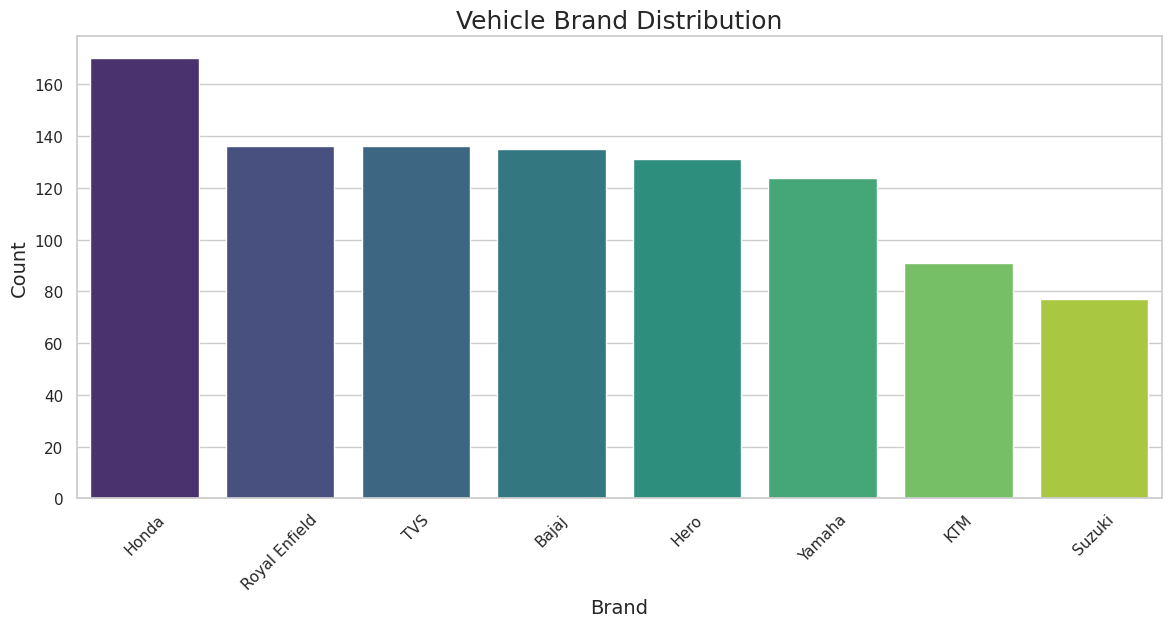

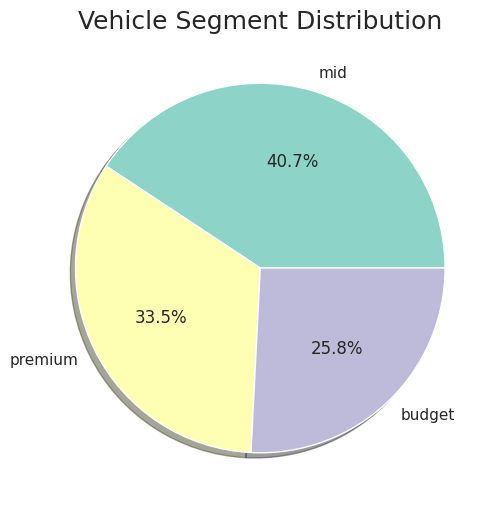

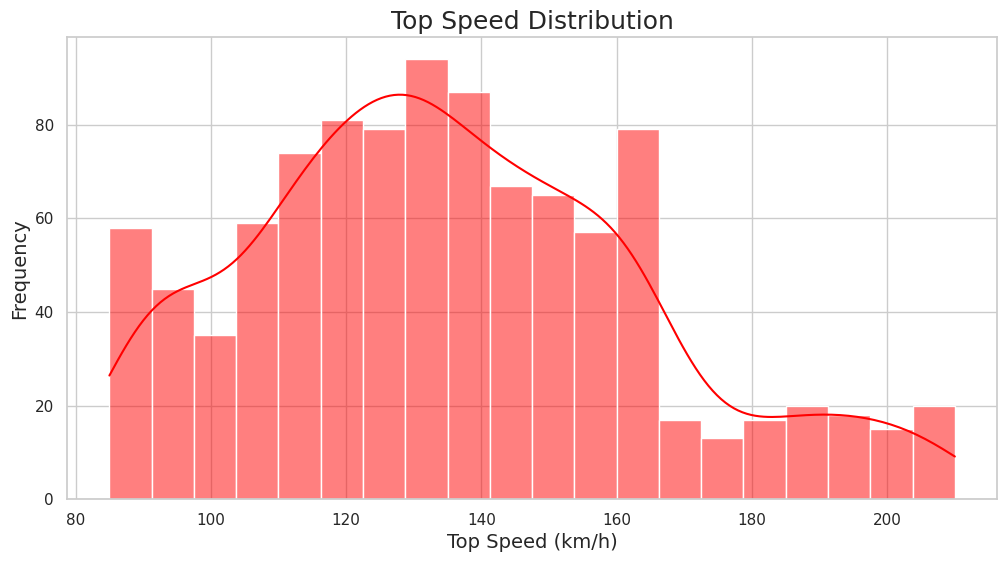

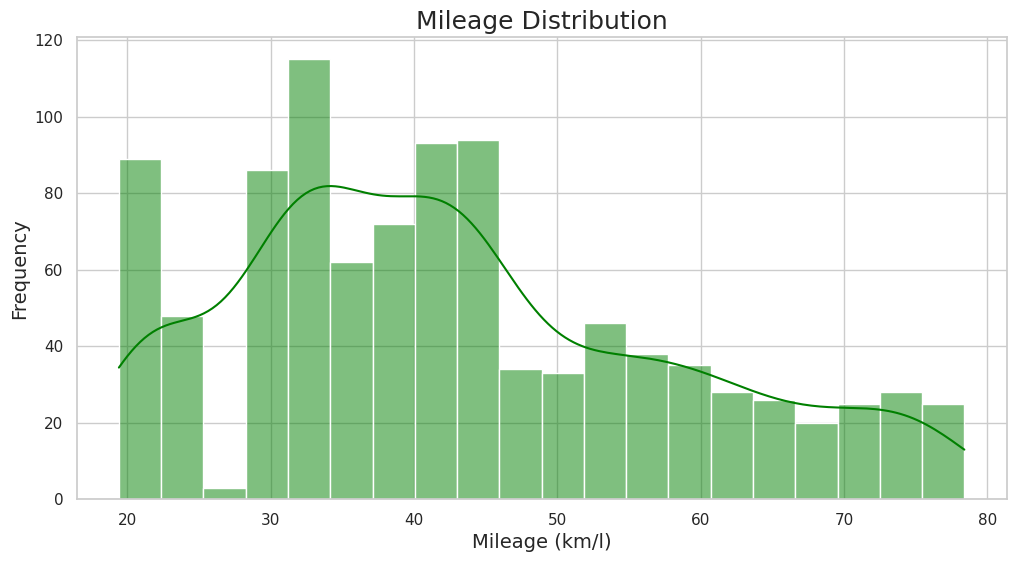

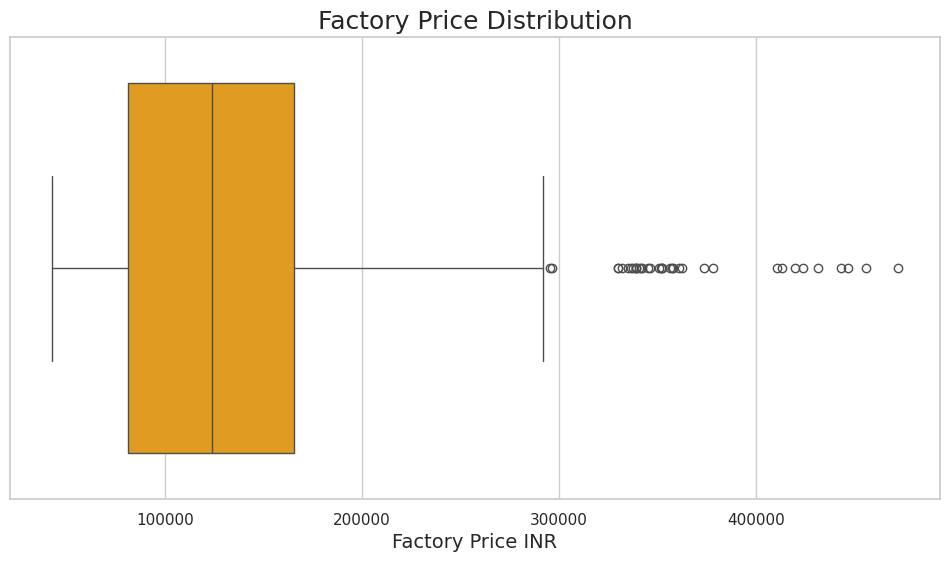

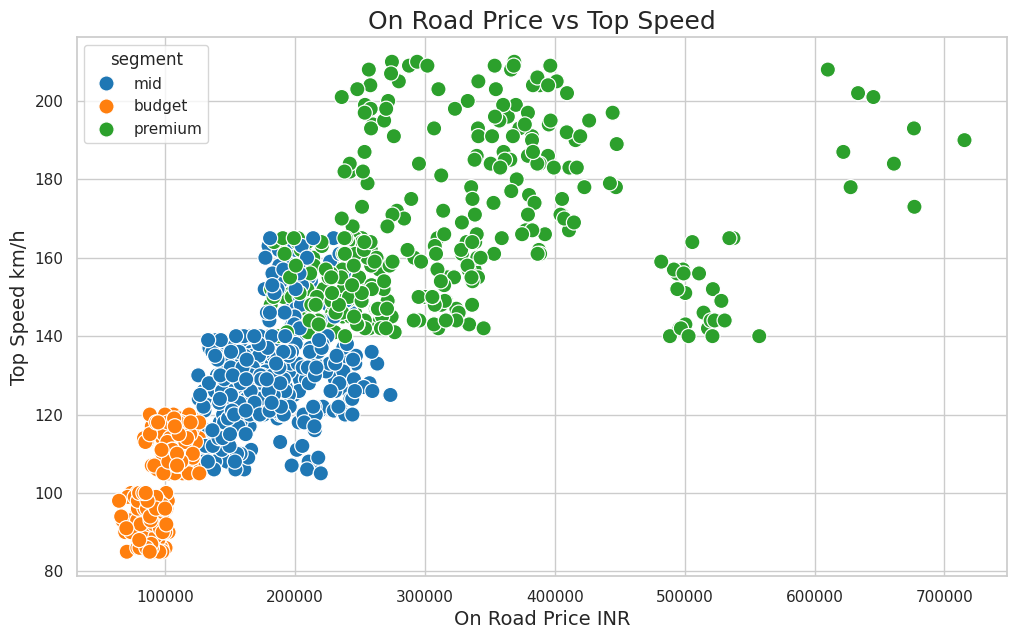

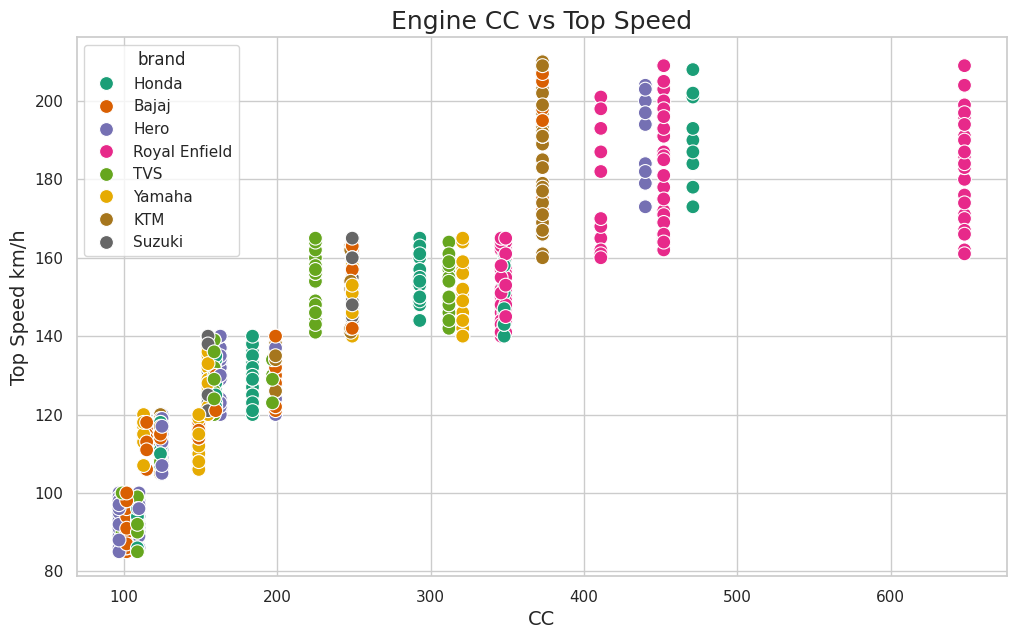

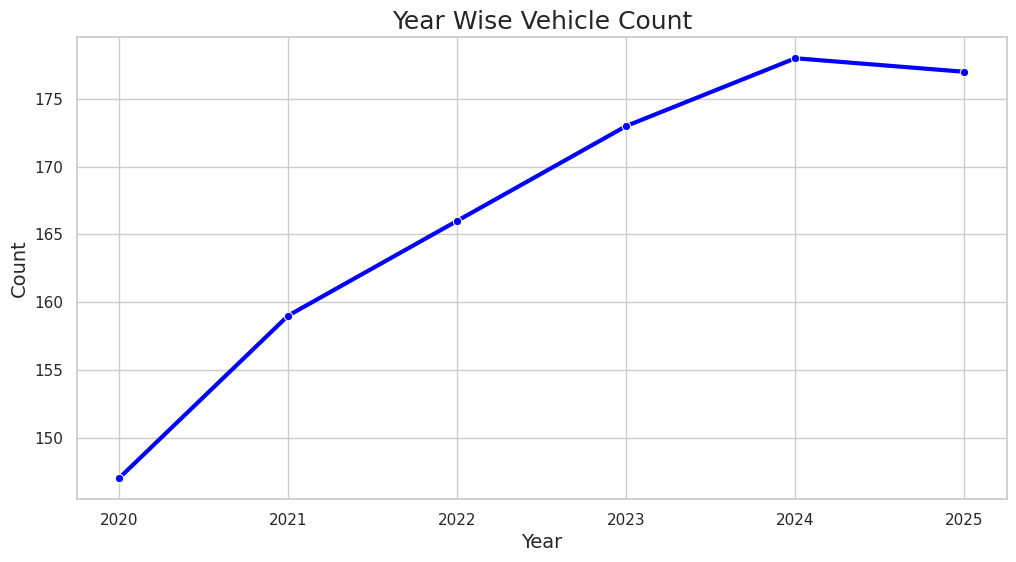

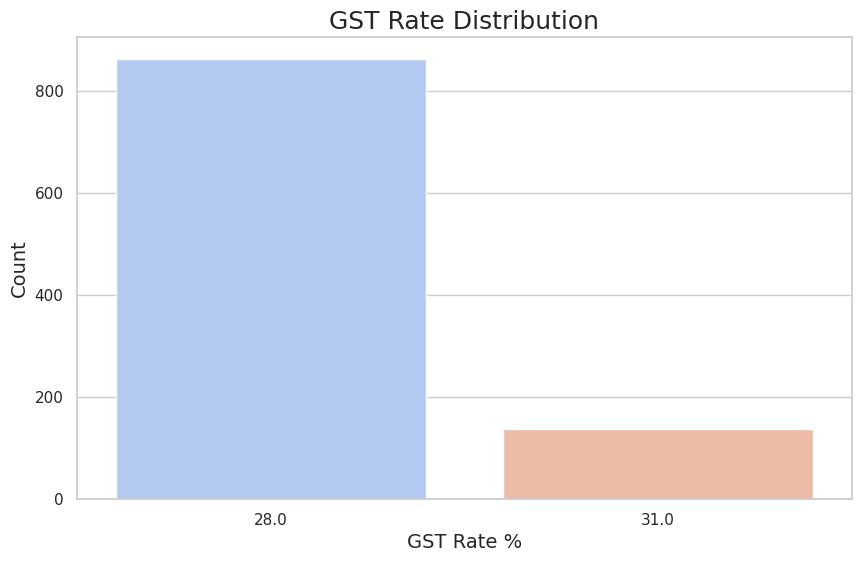

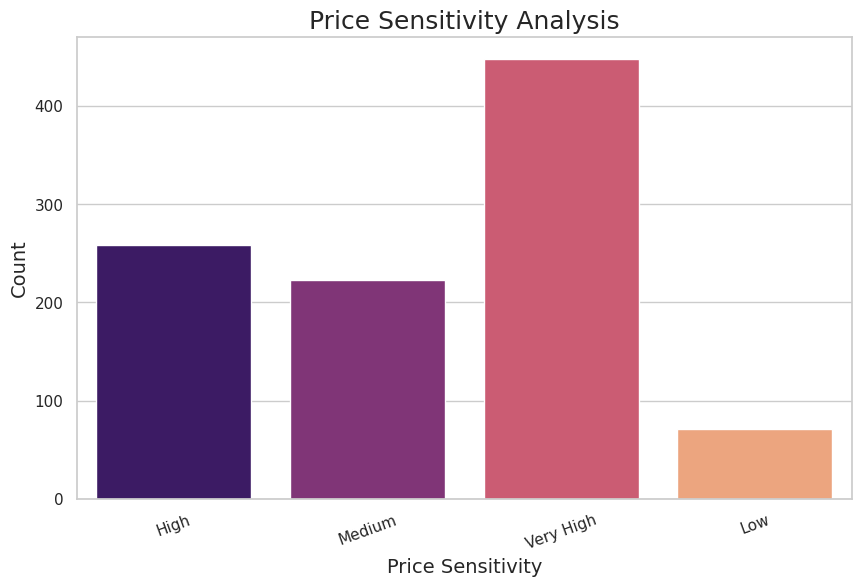

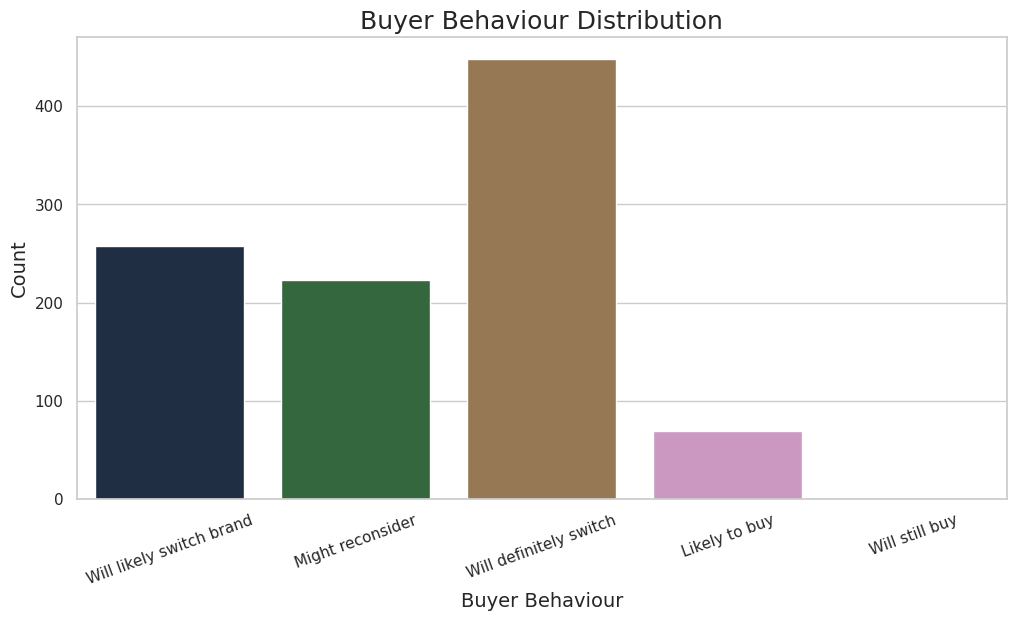

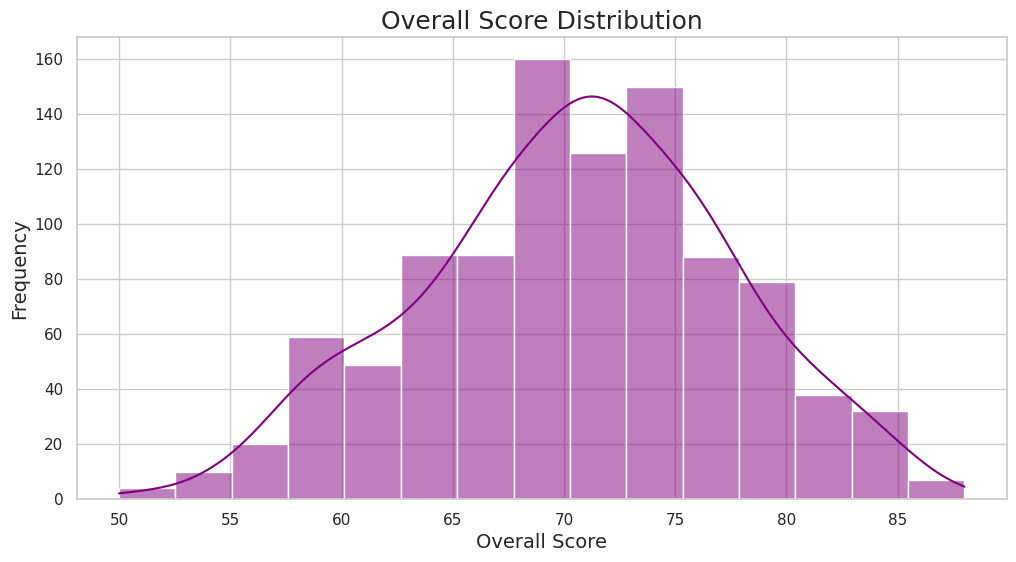

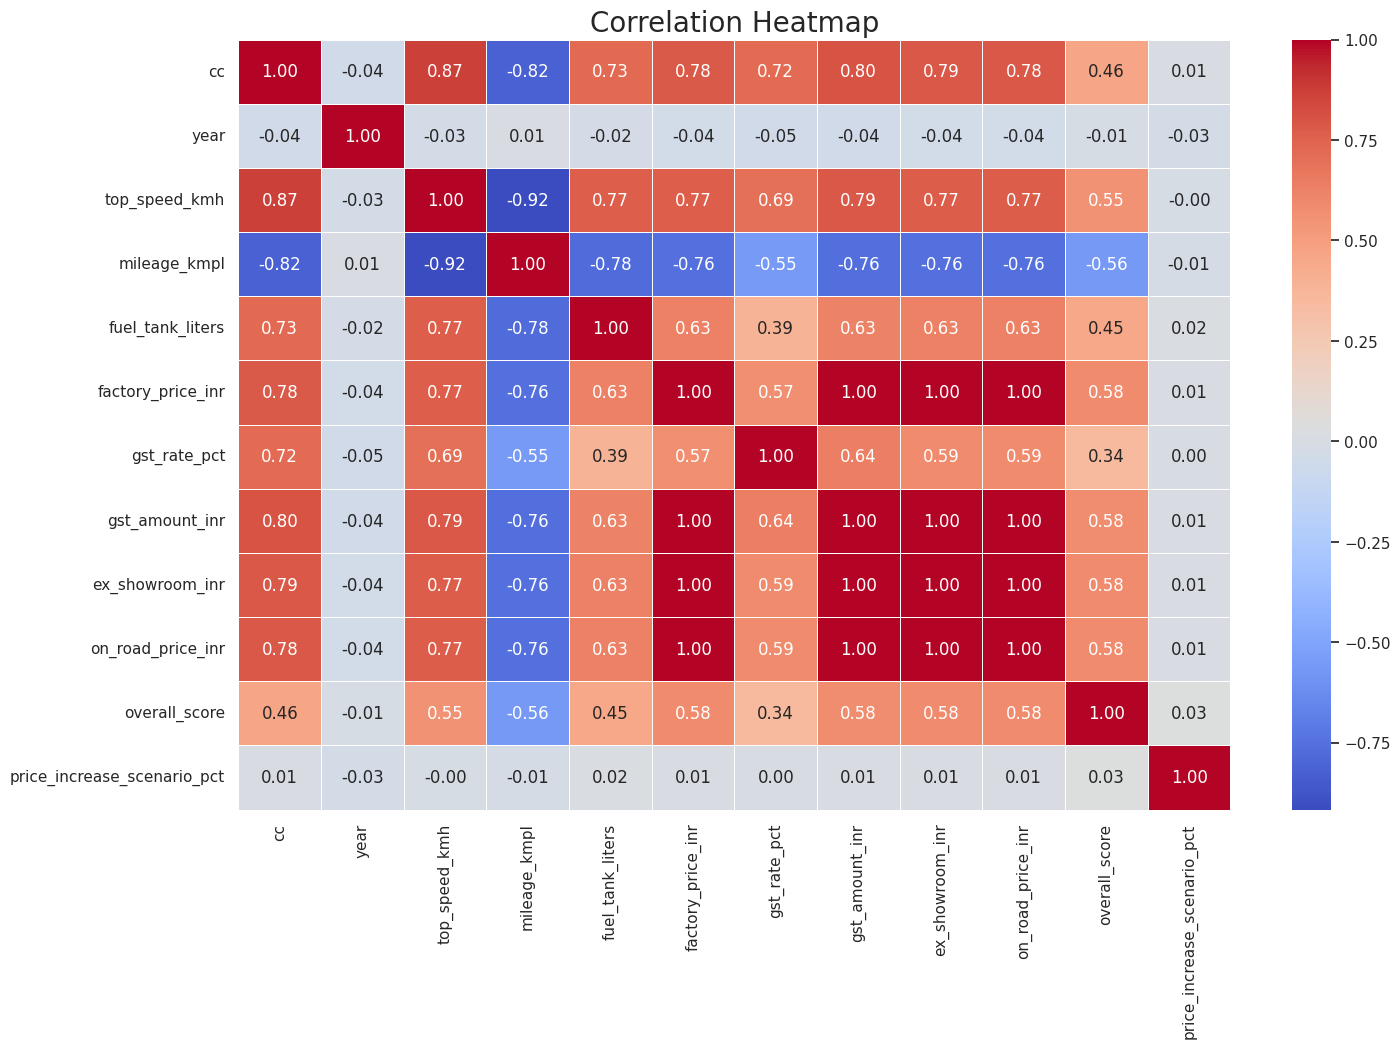

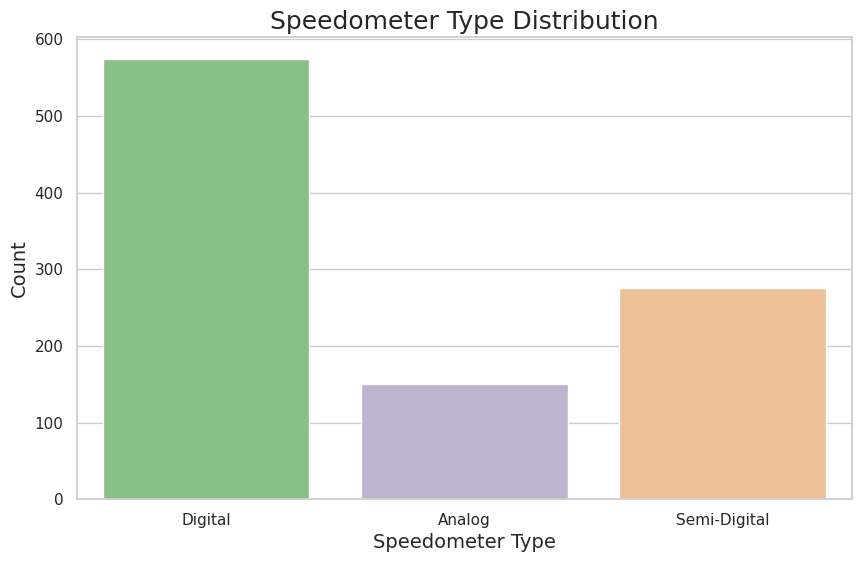

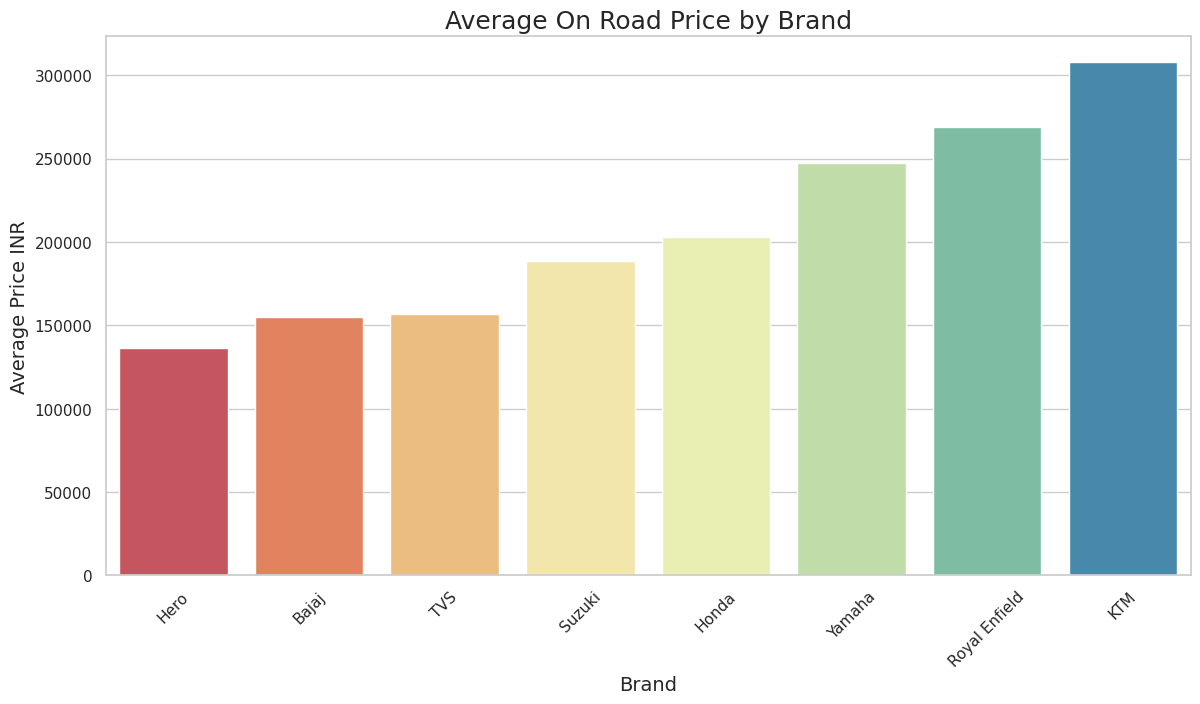

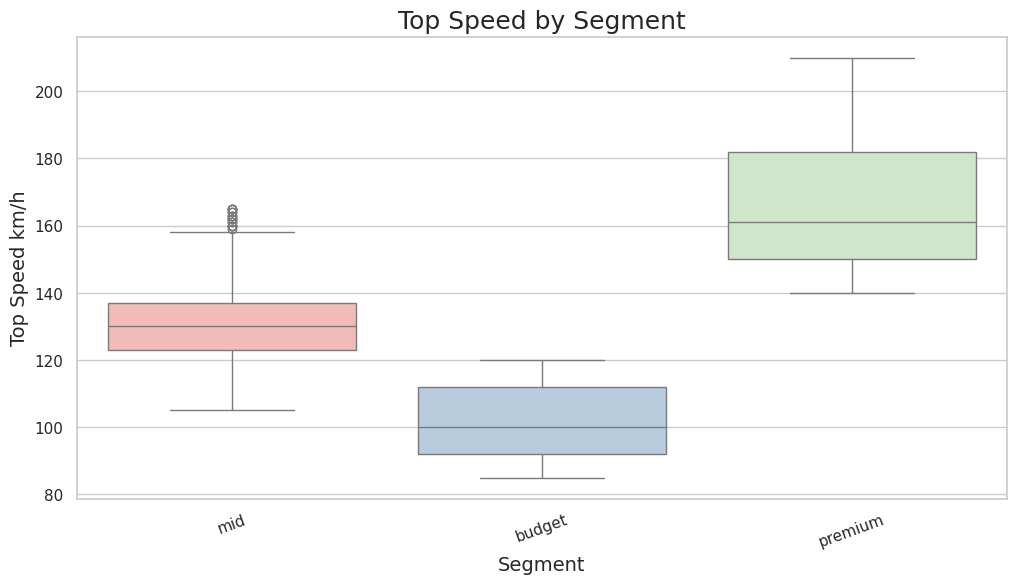

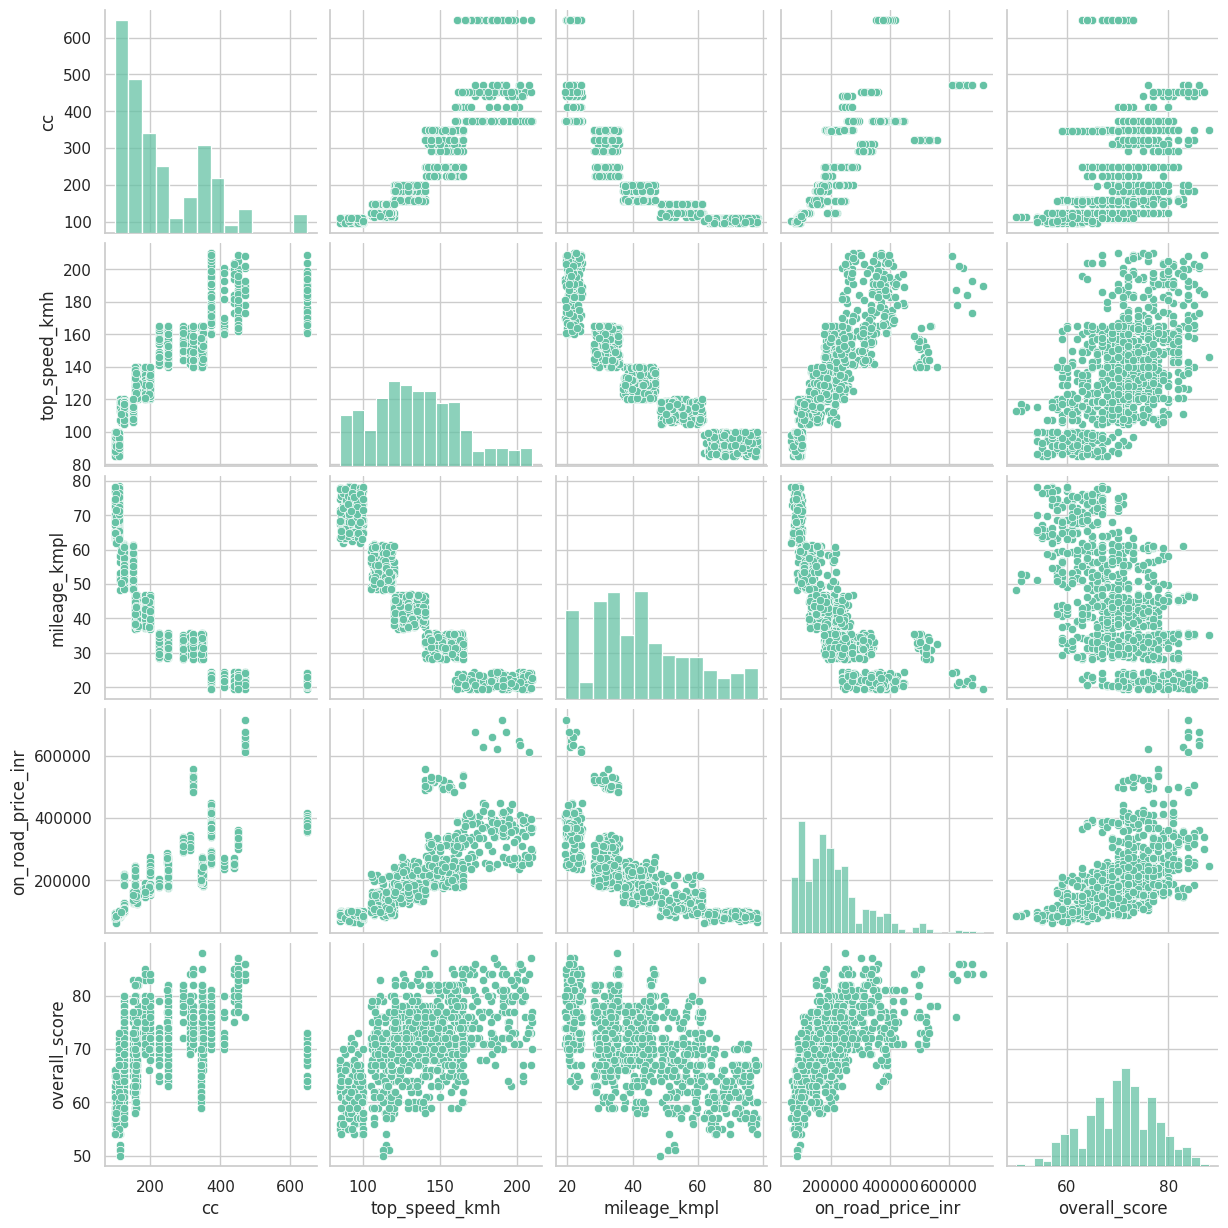

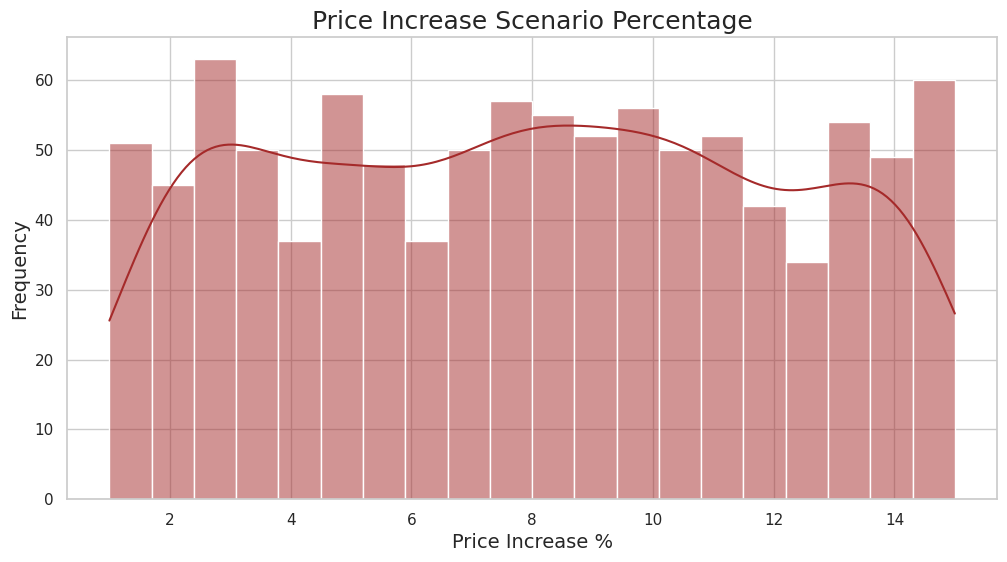

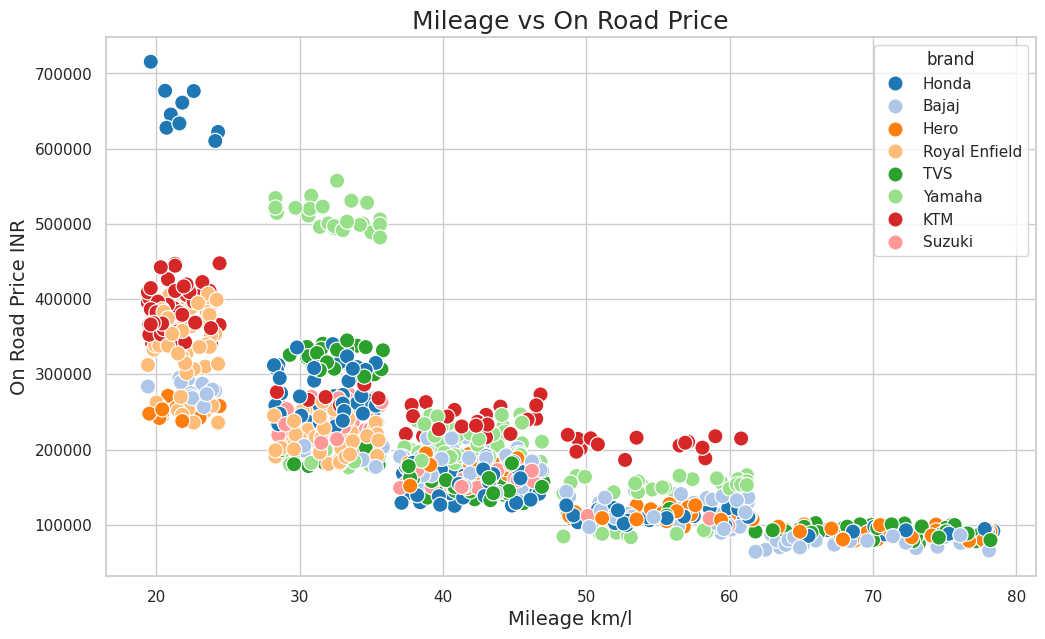


Visualization Completed Successfully
Total Visualizations Created: 20


In [13]:
plt.style.use('ggplot')

sns.set(
    style="whitegrid",
    palette="Set2"
)

# ============================================================
# 1. BRAND DISTRIBUTION
# ============================================================

plt.figure(figsize=(14,6))

brand_counts = df['brand'].value_counts()

sns.barplot(
    x=brand_counts.index,
    y=brand_counts.values,
    palette='viridis'
)

plt.title("Vehicle Brand Distribution", fontsize=18)
plt.xlabel("Brand", fontsize=14)
plt.ylabel("Count", fontsize=14)

plt.xticks(rotation=45)

plt.show()

# ============================================================
# 2. SEGMENT DISTRIBUTION
# ============================================================

plt.figure(figsize=(10,6))

segment_counts = df['segment'].value_counts()

colors = sns.color_palette('Set3', len(segment_counts))

plt.pie(
    segment_counts.values,
    labels=segment_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    shadow=True
)

plt.title("Vehicle Segment Distribution", fontsize=18)

plt.show()

# ============================================================
# 3. TOP SPEED DISTRIBUTION
# ============================================================

plt.figure(figsize=(12,6))

sns.histplot(
    df['top_speed_kmh'],
    bins=20,
    kde=True,
    color='red'
)

plt.title("Top Speed Distribution", fontsize=18)
plt.xlabel("Top Speed (km/h)", fontsize=14)
plt.ylabel("Frequency", fontsize=14)

plt.show()

# ============================================================
# 4. MILEAGE DISTRIBUTION
# ============================================================

plt.figure(figsize=(12,6))

sns.histplot(
    df['mileage_kmpl'],
    bins=20,
    kde=True,
    color='green'
)

plt.title("Mileage Distribution", fontsize=18)
plt.xlabel("Mileage (km/l)", fontsize=14)
plt.ylabel("Frequency", fontsize=14)

plt.show()

# ============================================================
# 5. FACTORY PRICE DISTRIBUTION
# ============================================================

plt.figure(figsize=(12,6))

sns.boxplot(
    x=df['factory_price_inr'],
    color='orange'
)

plt.title("Factory Price Distribution", fontsize=18)

plt.xlabel("Factory Price INR", fontsize=14)

plt.show()

# ============================================================
# 6. ON ROAD PRICE VS TOP SPEED
# ============================================================

plt.figure(figsize=(12,7))

sns.scatterplot(
    data=df,
    x='on_road_price_inr',
    y='top_speed_kmh',
    hue='segment',
    palette='tab10',
    s=120
)

plt.title("On Road Price vs Top Speed", fontsize=18)

plt.xlabel("On Road Price INR", fontsize=14)
plt.ylabel("Top Speed km/h", fontsize=14)

plt.show()

# ============================================================
# 7. CC VS TOP SPEED
# ============================================================

plt.figure(figsize=(12,7))

sns.scatterplot(
    data=df,
    x='cc',
    y='top_speed_kmh',
    hue='brand',
    palette='Dark2',
    s=100
)

plt.title("Engine CC vs Top Speed", fontsize=18)

plt.xlabel("CC", fontsize=14)
plt.ylabel("Top Speed km/h", fontsize=14)

plt.show()

# ============================================================
# 8. YEAR WISE VEHICLE COUNT
# ============================================================

plt.figure(figsize=(12,6))

year_counts = df['year'].value_counts().sort_index()

sns.lineplot(
    x=year_counts.index,
    y=year_counts.values,
    marker='o',
    color='blue',
    linewidth=3
)

plt.title("Year Wise Vehicle Count", fontsize=18)

plt.xlabel("Year", fontsize=14)
plt.ylabel("Count", fontsize=14)

plt.show()

# ============================================================
# 9. GST RATE ANALYSIS
# ============================================================

plt.figure(figsize=(10,6))

sns.countplot(
    x='gst_rate_pct',
    data=df,
    palette='coolwarm'
)

plt.title("GST Rate Distribution", fontsize=18)

plt.xlabel("GST Rate %", fontsize=14)
plt.ylabel("Count", fontsize=14)

plt.show()

# ============================================================
# 10. PRICE SENSITIVITY ANALYSIS
# ============================================================

plt.figure(figsize=(10,6))

sns.countplot(
    x='price_sensitivity',
    data=df,
    palette='magma'
)

plt.title("Price Sensitivity Analysis", fontsize=18)

plt.xlabel("Price Sensitivity", fontsize=14)
plt.ylabel("Count", fontsize=14)

plt.xticks(rotation=20)

plt.show()

# ============================================================
# 11. BUYER BEHAVIOUR ANALYSIS
# ============================================================

plt.figure(figsize=(12,6))

sns.countplot(
    x='buyer_behaviour',
    data=df,
    palette='cubehelix'
)

plt.title("Buyer Behaviour Distribution", fontsize=18)

plt.xlabel("Buyer Behaviour", fontsize=14)
plt.ylabel("Count", fontsize=14)

plt.xticks(rotation=20)

plt.show()

# ============================================================
# 12. OVERALL SCORE DISTRIBUTION
# ============================================================

plt.figure(figsize=(12,6))

sns.histplot(
    df['overall_score'],
    bins=15,
    kde=True,
    color='purple'
)

plt.title("Overall Score Distribution", fontsize=18)

plt.xlabel("Overall Score", fontsize=14)
plt.ylabel("Frequency", fontsize=14)

plt.show()

# ============================================================
# 13. HEATMAP CORRELATION
# ============================================================

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(16,10))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=20)

plt.show()

# ============================================================
# 14. SPEEDOMETER TYPE ANALYSIS
# ============================================================

plt.figure(figsize=(10,6))

sns.countplot(
    x='speedometer_type',
    data=df,
    palette='Accent'
)

plt.title("Speedometer Type Distribution", fontsize=18)

plt.xlabel("Speedometer Type", fontsize=14)
plt.ylabel("Count", fontsize=14)

plt.show()

# ============================================================
# 15. AVG ON ROAD PRICE BY BRAND
# ============================================================

avg_price = df.groupby('brand')['on_road_price_inr'].mean().sort_values()

plt.figure(figsize=(14,7))

sns.barplot(
    x=avg_price.index,
    y=avg_price.values,
    palette='Spectral'
)

plt.title("Average On Road Price by Brand", fontsize=18)

plt.xlabel("Brand", fontsize=14)
plt.ylabel("Average Price INR", fontsize=14)

plt.xticks(rotation=45)

plt.show()

# ============================================================
# 16. TOP SPEED BY SEGMENT
# ============================================================

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x='segment',
    y='top_speed_kmh',
    palette='Pastel1'
)

plt.title("Top Speed by Segment", fontsize=18)

plt.xlabel("Segment", fontsize=14)
plt.ylabel("Top Speed km/h", fontsize=14)

plt.xticks(rotation=20)

plt.show()

# ============================================================
# 17. PAIRPLOT
# ============================================================

selected_cols = [
    'cc',
    'top_speed_kmh',
    'mileage_kmpl',
    'on_road_price_inr',
    'overall_score'
]

sns.pairplot(
    df[selected_cols],
    palette='husl'
)

plt.show()

# ============================================================
# 18. PRICE INCREASE SCENARIO ANALYSIS
# ============================================================

plt.figure(figsize=(12,6))

sns.histplot(
    df['price_increase_scenario_pct'],
    bins=20,
    kde=True,
    color='brown'
)

plt.title("Price Increase Scenario Percentage", fontsize=18)

plt.xlabel("Price Increase %", fontsize=14)
plt.ylabel("Frequency", fontsize=14)

plt.show()

# ============================================================
# 19. MILEAGE VS PRICE
# ============================================================

plt.figure(figsize=(12,7))

sns.scatterplot(
    data=df,
    x='mileage_kmpl',
    y='on_road_price_inr',
    hue='brand',
    palette='tab20',
    s=120
)

plt.title("Mileage vs On Road Price", fontsize=18)

plt.xlabel("Mileage km/l", fontsize=14)
plt.ylabel("On Road Price INR", fontsize=14)

plt.show()

# ============================================================
# 20. FINAL SUMMARY
# ============================================================

print("\nVisualization Completed Successfully")
print("Total Visualizations Created: 20")

## Feature engineering


Train Shape
(800, 17)

Test Shape
(200, 17)

Categorical Columns
Index(['brand', 'model', 'segment', 'speedometer_type', 'buyer_behaviour'], dtype='object')

Numerical Columns
Index(['cc', 'year', 'top_speed_kmh', 'mileage_kmpl', 'fuel_tank_liters',
       'factory_price_inr', 'gst_rate_pct', 'gst_amount_inr',
       'ex_showroom_inr', 'on_road_price_inr', 'overall_score',
       'price_increase_scenario_pct'],
      dtype='object')


MODEL : Logistic Regression

Accuracy Score : 0.4350

Classification Report

              precision    recall  f1-score   support

        High       0.31      0.08      0.12        52
         Low       0.00      0.00      0.00        14
      Medium       0.00      0.00      0.00        45
   Very High       0.45      0.93      0.60        89

    accuracy                           0.43       200
   macro avg       0.19      0.25      0.18       200
weighted avg       0.28      0.43      0.30       200



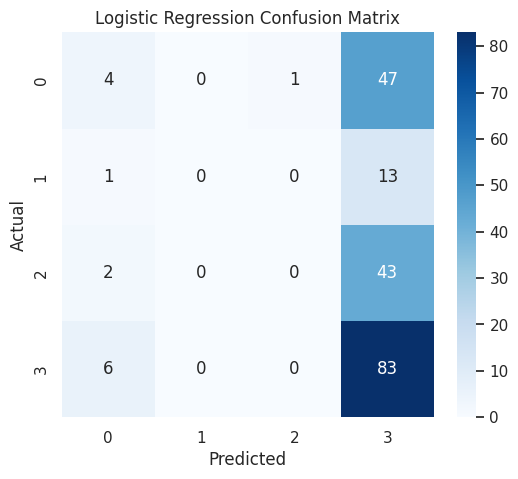



MODEL : Decision Tree

Accuracy Score : 1.0000

Classification Report

              precision    recall  f1-score   support

        High       1.00      1.00      1.00        52
         Low       1.00      1.00      1.00        14
      Medium       1.00      1.00      1.00        45
   Very High       1.00      1.00      1.00        89

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



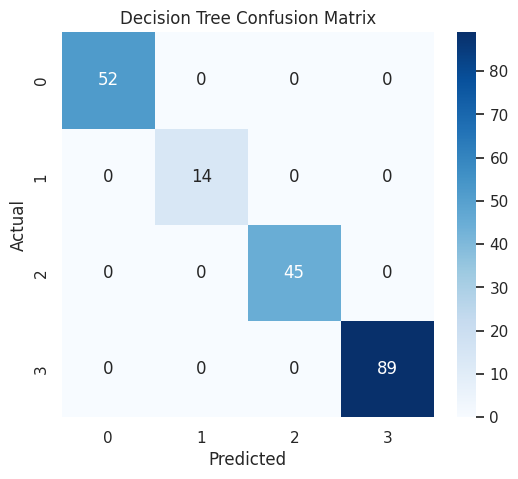



MODEL : Random Forest

Accuracy Score : 1.0000

Classification Report

              precision    recall  f1-score   support

        High       1.00      1.00      1.00        52
         Low       1.00      1.00      1.00        14
      Medium       1.00      1.00      1.00        45
   Very High       1.00      1.00      1.00        89

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



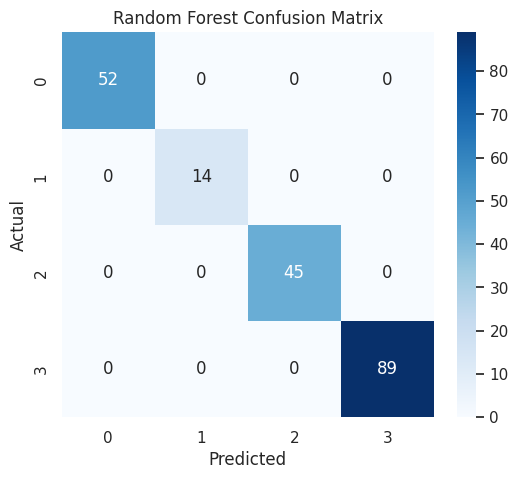



MODEL : Gradient Boosting

Accuracy Score : 1.0000

Classification Report

              precision    recall  f1-score   support

        High       1.00      1.00      1.00        52
         Low       1.00      1.00      1.00        14
      Medium       1.00      1.00      1.00        45
   Very High       1.00      1.00      1.00        89

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



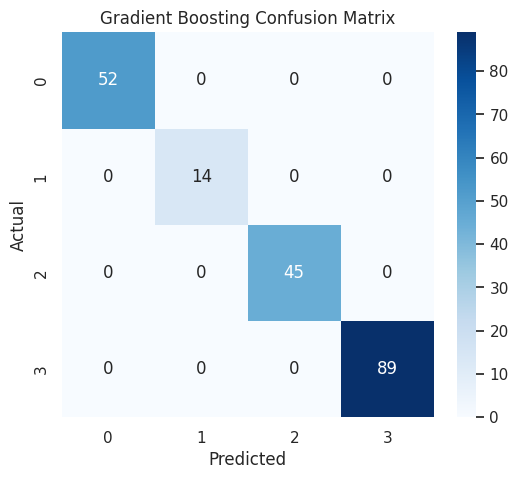



MODEL : KNN

Accuracy Score : 0.3050

Classification Report

              precision    recall  f1-score   support

        High       0.23      0.35      0.28        52
         Low       0.20      0.07      0.11        14
      Medium       0.21      0.18      0.19        45
   Very High       0.44      0.38      0.41        89

    accuracy                           0.30       200
   macro avg       0.27      0.24      0.24       200
weighted avg       0.31      0.30      0.30       200



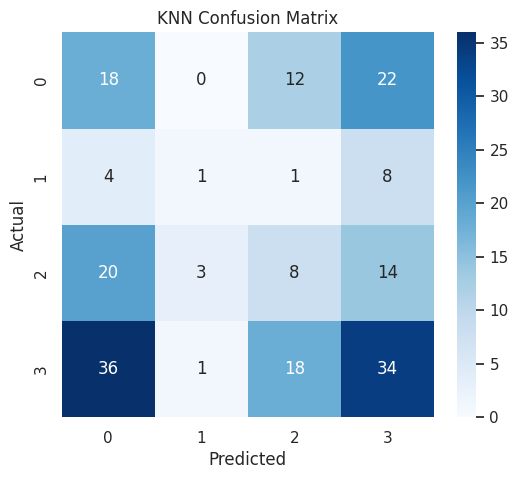



MODEL : SVM

Accuracy Score : 0.4450

Classification Report

              precision    recall  f1-score   support

        High       0.00      0.00      0.00        52
         Low       0.00      0.00      0.00        14
      Medium       0.00      0.00      0.00        45
   Very High       0.45      1.00      0.62        89

    accuracy                           0.45       200
   macro avg       0.11      0.25      0.15       200
weighted avg       0.20      0.45      0.27       200



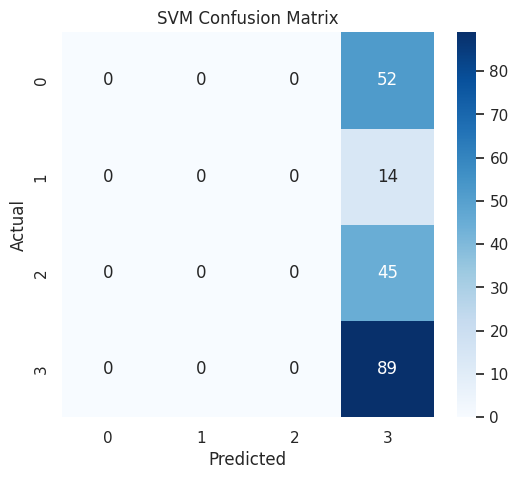



MODEL ACCURACY COMPARISON
                 Model  Accuracy
1        Decision Tree     1.000
2        Random Forest     1.000
3    Gradient Boosting     1.000
5                  SVM     0.445
0  Logistic Regression     0.435
4                  KNN     0.305


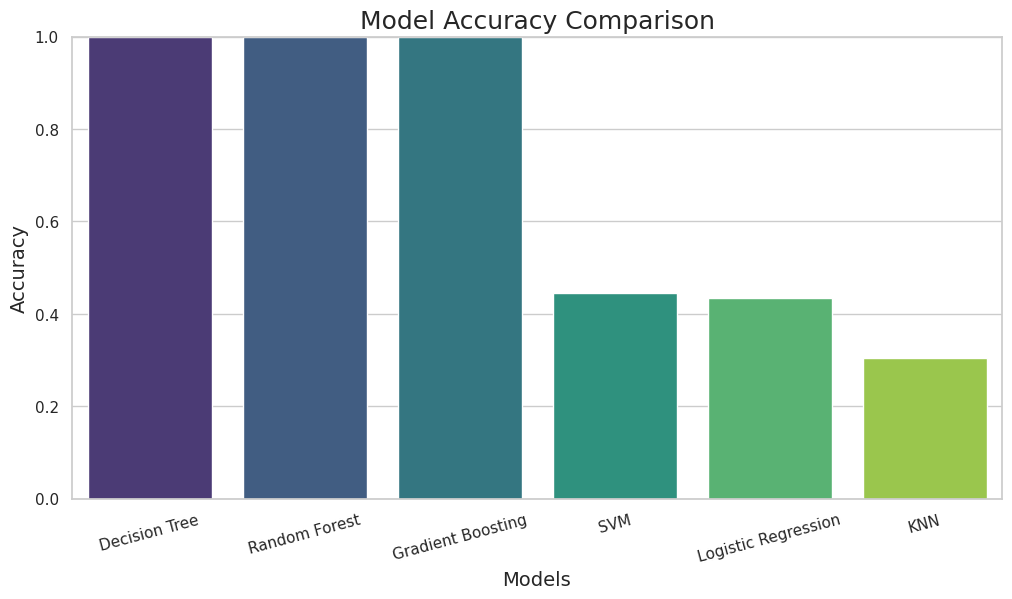

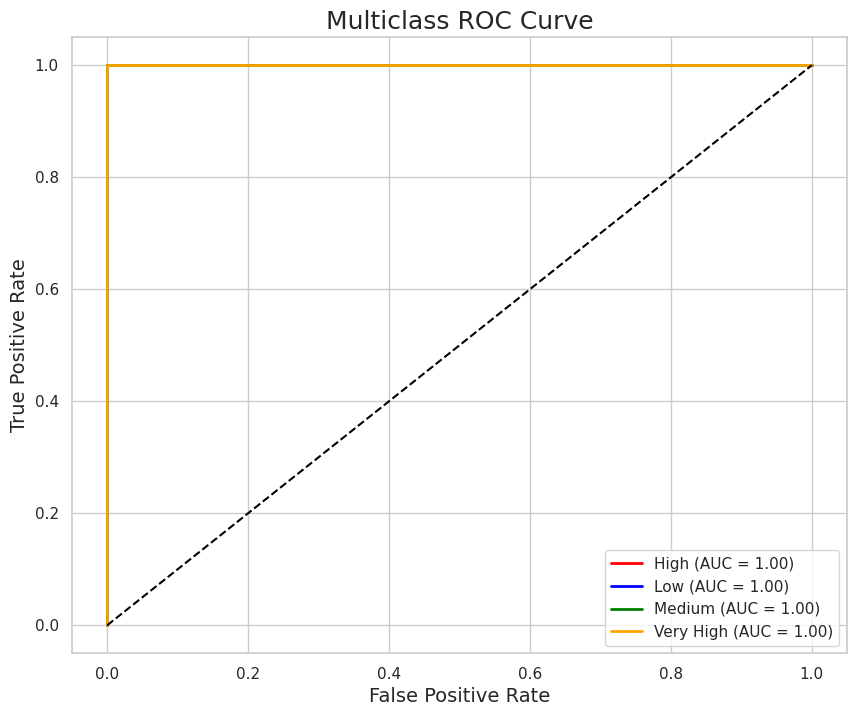

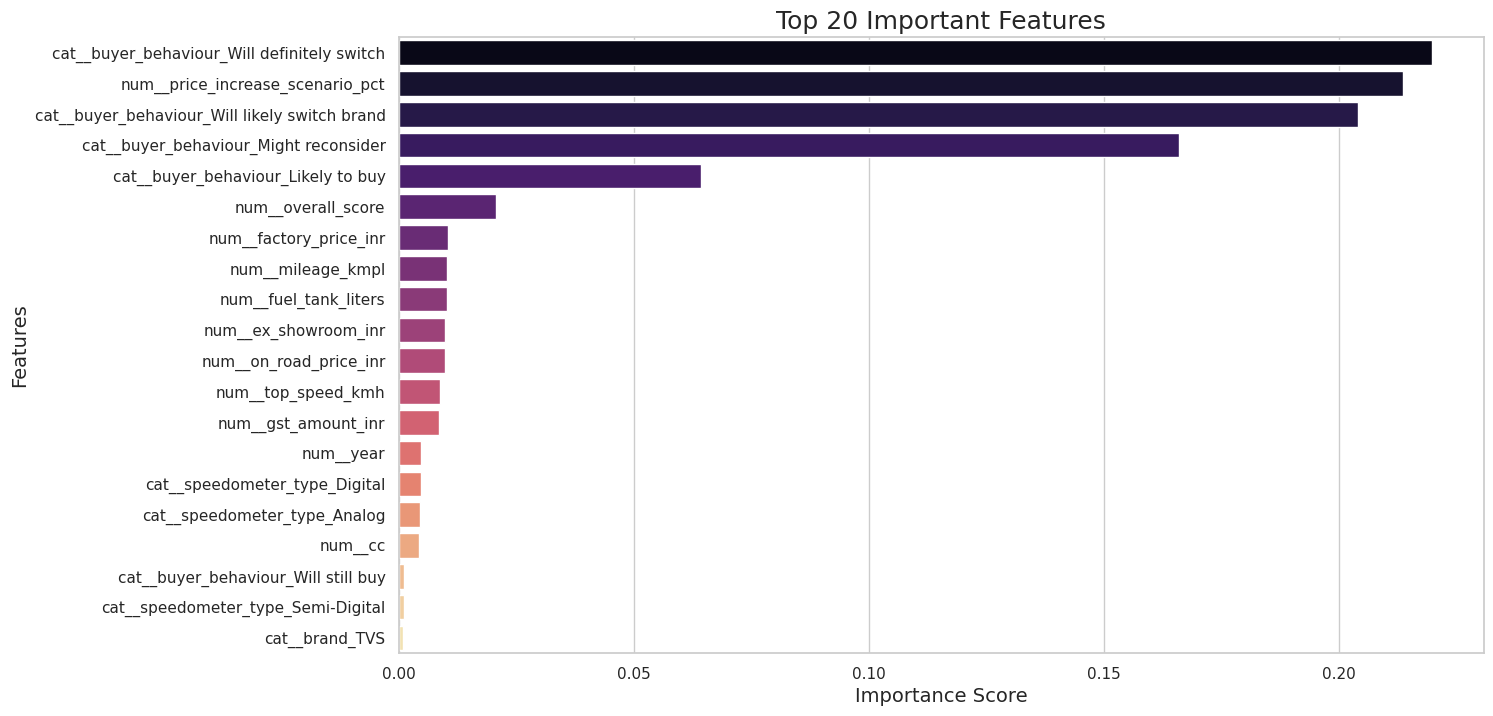



BEST MODEL
Model Name : Decision Tree
Accuracy   : 1.0000

Model Saved Successfully

Machine Learning Pipeline Completed Successfully


In [14]:
# Train Test Split
from sklearn.model_selection import train_test_split

# Encoding
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

# Missing Values
from sklearn.impute import SimpleImputer

# ML Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

# For multiclass ROC
from sklearn.preprocessing import label_binarize


target_column = 'price_sensitivity'

# ============================================================
# FEATURES AND TARGET
# ============================================================

X = df.drop(target_column, axis=1)
y = df[target_column]

# ============================================================
# TRAIN TEST SPLIT
# IMPORTANT:
# SPLIT BEFORE ENCODING
# TO AVOID DATA LEAKAGE
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTrain Shape")
print(X_train.shape)

print("\nTest Shape")
print(X_test.shape)

# ============================================================
# CATEGORICAL AND NUMERICAL COLUMNS
# ============================================================

categorical_cols = X.select_dtypes(include=['object']).columns

numerical_cols = X.select_dtypes(exclude=['object']).columns

print("\nCategorical Columns")
print(categorical_cols)

print("\nNumerical Columns")
print(numerical_cols)

# ============================================================
# PREPROCESSING PIPELINE
# ============================================================

# Numerical Transformer
numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median'))
    ]
)

# Categorical Transformer
categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]
)

# Combine Transformers
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# ============================================================
# MACHINE LEARNING MODELS
# ============================================================

models = {

    "Logistic Regression":
        LogisticRegression(max_iter=500),

    "Decision Tree":
        DecisionTreeClassifier(max_depth=6),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            max_depth=8,
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(),

    "KNN":
        KNeighborsClassifier(n_neighbors=5),

    "SVM":
        SVC(probability=True)
}

# ============================================================
# STORE RESULTS
# ============================================================

accuracy_results = {}

# ============================================================
# TRAINING LOOP
# ============================================================

for name, model in models.items():

    print("\n")
    print("="*60)
    print(f"MODEL : {name}")
    print("="*60)

    # ========================================================
    # CREATE PIPELINE
    # ========================================================

    pipeline = Pipeline(
        steps=[
            ('preprocessor', preprocessor),
            ('model', model)
        ]
    )

    # ========================================================
    # TRAIN MODEL
    # ========================================================

    pipeline.fit(X_train, y_train)

    # ========================================================
    # PREDICTIONS
    # ========================================================

    y_pred = pipeline.predict(X_test)

    # ========================================================
    # ACCURACY
    # ========================================================

    accuracy = accuracy_score(y_test, y_pred)

    accuracy_results[name] = accuracy

    print(f"\nAccuracy Score : {accuracy:.4f}")

    # ========================================================
    # CLASSIFICATION REPORT
    # ========================================================

    print("\nClassification Report\n")

    print(classification_report(y_test, y_pred))

    # ========================================================
    # CONFUSION MATRIX
    # ========================================================

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f'{name} Confusion Matrix')

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

# ============================================================
# ACCURACY COMPARISON
# ============================================================

accuracy_df = pd.DataFrame({
    'Model': accuracy_results.keys(),
    'Accuracy': accuracy_results.values()
})

accuracy_df = accuracy_df.sort_values(
    by='Accuracy',
    ascending=False
)

print("\n")
print("="*60)
print("MODEL ACCURACY COMPARISON")
print("="*60)

print(accuracy_df)

# ============================================================
# BARPLOT OF ACCURACY
# ============================================================

plt.figure(figsize=(12,6))

sns.barplot(
    data=accuracy_df,
    x='Model',
    y='Accuracy',
    palette='viridis'
)

plt.title("Model Accuracy Comparison", fontsize=18)

plt.xlabel("Models", fontsize=14)
plt.ylabel("Accuracy", fontsize=14)

plt.xticks(rotation=15)

plt.ylim(0,1)

plt.show()

# ============================================================
# ROC CURVE
# ============================================================

# Use Random Forest for ROC Curve
best_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ))
    ]
)

# Train
best_model.fit(X_train, y_train)

# ============================================================
# MULTICLASS ROC
# ============================================================

# Convert target into binary format
classes = np.unique(y_test)

y_test_bin = label_binarize(y_test, classes=classes)

# Predict probabilities
y_prob = best_model.predict_proba(X_test)

# ============================================================
# ROC CURVE PLOT
# ============================================================

plt.figure(figsize=(10,8))

colors = [
    'red',
    'blue',
    'green',
    'orange',
    'purple',
    'brown',
    'pink'
]

for i in range(len(classes)):

    fpr, tpr, thresholds = roc_curve(
        y_test_bin[:, i],
        y_prob[:, i]
    )

    auc_score = roc_auc_score(
        y_test_bin[:, i],
        y_prob[:, i]
    )

    plt.plot(
        fpr,
        tpr,
        color=colors[i % len(colors)],
        lw=2,
        label=f'{classes[i]} (AUC = {auc_score:.2f})'
    )

# Random line
plt.plot(
    [0,1],
    [0,1],
    color='black',
    linestyle='--'
)

plt.title("Multiclass ROC Curve", fontsize=18)

plt.xlabel("False Positive Rate", fontsize=14)
plt.ylabel("True Positive Rate", fontsize=14)

plt.legend()

plt.show()

# ============================================================
# FEATURE IMPORTANCE
# ============================================================

# Train Random Forest separately
rf_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ))
    ]
)

rf_model.fit(X_train, y_train)

# ============================================================
# GET FEATURE NAMES
# ============================================================

encoded_feature_names = rf_model.named_steps[
    'preprocessor'
].get_feature_names_out()

# Get feature importances
feature_importance = rf_model.named_steps[
    'model'
].feature_importances_

# Create dataframe
importance_df = pd.DataFrame({
    'Feature': encoded_feature_names,
    'Importance': feature_importance
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

# Top 20 features
top_features = importance_df.head(20)

# ============================================================
# FEATURE IMPORTANCE PLOT
# ============================================================

plt.figure(figsize=(14,8))

sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature',
    palette='magma'
)

plt.title("Top 20 Important Features", fontsize=18)

plt.xlabel("Importance Score", fontsize=14)
plt.ylabel("Features", fontsize=14)

plt.show()

# ============================================================
# BEST MODEL
# ============================================================

best_accuracy = accuracy_df.iloc[0]

print("\n")
print("="*60)
print("BEST MODEL")
print("="*60)

print(f"Model Name : {best_accuracy['Model']}")
print(f"Accuracy   : {best_accuracy['Accuracy']:.4f}")

# ============================================================
# SAVE BEST MODEL
# ============================================================

import joblib

joblib.dump(best_model, "best_vehicle_model.pkl")

print("\nModel Saved Successfully")

# ============================================================
# END PROJECT
# ============================================================

print("\nMachine Learning Pipeline Completed Successfully")

## Thank you...pls upvote!!!!!!!!!!!